In [1]:
import json

import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import resnet50
from tqdm.auto import tqdm

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"device: {device}")

device: cuda


In [3]:
EXP_ID = "exp07"
RUN_NAME = "exp07_resnet50_radimagenet_mammobench_frozen_linearhead"
UNFROZEN_DESC = "backbone completamente congelado"
BLOCK = 3
HEAD = "linear"

LR = 1e-3
WEIGHT_DECAY = 1e-4
BATCH_SIZE = 32
NUM_EPOCHS = 100
PATIENCE = 20
IMAGE_SIZE = 224
ROTATION_DEGREES = 10

PROJECT_ROOT = Path(
    "/media/imagenesmedicas/DATA1/01-ImagenesMedicas-US1/13-PregradoJulian/"
    "Federal Learning/infraestructura federada/Federal-Learning"
)

DATASET_ROOT = Path(
    "/media/imagenesmedicas/DATA1/01-ImagenesMedicas-US1/02-Databases/Mammo-Bench/"
    "c86fb00c-0fb8-4e0e-85a2-4d415f9c1ada_1a9410d8-9769-4064-a064-0160f2fd193d_"
    "DATASET-FILE_Mammo_Bench_zip_20241225112148174/Mammo_Data/Mammo-Bench"
)
MANIFEST_PATH = PROJECT_ROOT / "manifests" / "fedmammobench.csv"
RADIMAGENET_WEIGHTS_PATH = PROJECT_ROOT / "weights" / "RadImageNet-resnet50.pth"

RUN_DIR = PROJECT_ROOT / "runs" / RUN_NAME
PLOTS_DIR = RUN_DIR / "plots"
RUN_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

BEST_MODEL_PATH = RUN_DIR / "best_model.pth"
LAST_MODEL_PATH = RUN_DIR / "last_model.pth"

print(f"RUN_DIR: {RUN_DIR}")

RUN_DIR: /media/imagenesmedicas/DATA1/01-ImagenesMedicas-US1/13-PregradoJulian/Federal Learning/infraestructura federada/Federal-Learning/runs/exp07_resnet50_radimagenet_mammobench_frozen_linearhead


In [4]:
SPLIT_COL = "split"
LABEL_COL = "classification"
PATH_COL = "preprocessed_image_path"

TRAIN_SPLIT, VAL_SPLIT, TEST_SPLIT = "train", "val", "test"


class CSVDataset(Dataset):
    def __init__(self, csv_file, split, root_dir="", transform=None, label_to_idx=None):
        self.data = pd.read_csv(csv_file)

        missing = {SPLIT_COL, LABEL_COL, PATH_COL} - set(self.data.columns)
        if missing:
            raise KeyError(
                f"El manifest {csv_file} no tiene la(s) columna(s) {sorted(missing)}. "
                f"Columnas disponibles: {list(self.data.columns)}"
            )

        available = sorted(self.data[SPLIT_COL].dropna().unique())
        if split not in available:
            raise ValueError(
                f"split={split!r} no existe en la columna {SPLIT_COL!r}. "
                f"Valores disponibles: {available}"
            )

        self.data = self.data[self.data[SPLIT_COL] == split].reset_index(drop=True)
        if len(self.data) == 0:
            raise ValueError(f"El split {split!r} quedó vacío tras filtrar {csv_file}.")

        self.root_dir = Path(root_dir)
        self.transform = transform

        if label_to_idx is None:
            labels = sorted(self.data[LABEL_COL].unique())
            self.label_to_idx = {label: i for i, label in enumerate(labels)}
        else:
            self.label_to_idx = label_to_idx

        unknown = set(self.data[LABEL_COL].unique()) - set(self.label_to_idx)
        if unknown:
            raise ValueError(
                f"El split {split!r} tiene etiquetas {sorted(unknown)} ausentes en "
                f"label_to_idx={self.label_to_idx}."
            )

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]

        img_path = Path(self.root_dir) / Path(row[PATH_COL])
        image = Image.open(img_path).convert("RGB")

        label = self.label_to_idx[row[LABEL_COL]]

        if self.transform:
            image = self.transform(image)

        return image, label

In [5]:
_manifest = pd.read_csv(MANIFEST_PATH)

_required = {SPLIT_COL, LABEL_COL, PATH_COL}
assert _required <= set(_manifest.columns), (
    f"Faltan columnas en el manifest: {sorted(_required - set(_manifest.columns))}"
)

_splits = sorted(_manifest[SPLIT_COL].dropna().unique())
assert set(_splits) >= {TRAIN_SPLIT, VAL_SPLIT, TEST_SPLIT}, (
    f"El manifest solo tiene splits {_splits}; se esperaban "
    f"{[TRAIN_SPLIT, VAL_SPLIT, TEST_SPLIT]}"
)

print(f"Filas totales: {len(_manifest)}\n")
print(pd.crosstab(_manifest[SPLIT_COL], _manifest[LABEL_COL], margins=True))

if "source_dataset" in _manifest.columns:
    print()
    print(pd.crosstab(_manifest["source_dataset"], _manifest[SPLIT_COL], margins=True))

Filas totales: 8821

classification  Benign  Malignant   All
split                                  
test               425        455   880
train             3356       3701  7057
val                421        463   884
All               4202       4619  8821

split           test  train  val   All
source_dataset                        
cdd-cesm         100    803  100  1003
cmmd             518   4162  522  5202
inbreast          40    328   42   410
kau-bcmd         222   1764  220  2206
All              880   7057  884  8821


In [6]:
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomRotation(ROTATION_DEGREES),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

In [7]:
train_processed = CSVDataset(
    csv_file=MANIFEST_PATH, split=TRAIN_SPLIT, root_dir=DATASET_ROOT,
    transform=train_transform,
)
validation_processed = CSVDataset(
    csv_file=MANIFEST_PATH, split=VAL_SPLIT, root_dir=DATASET_ROOT,
    transform=val_transform, label_to_idx=train_processed.label_to_idx,
)
test_processed = CSVDataset(
    csv_file=MANIFEST_PATH, split=TEST_SPLIT, root_dir=DATASET_ROOT,
    transform=val_transform, label_to_idx=train_processed.label_to_idx,
)

print(f"label_to_idx: {train_processed.label_to_idx}")
print(f"train: {len(train_processed)} | val: {len(validation_processed)} | test: {len(test_processed)}")

label_to_idx: {'Benign': 0, 'Malignant': 1}
train: 7057 | val: 884 | test: 880


In [8]:
train = DataLoader(train_processed, batch_size=BATCH_SIZE, shuffle=True)
validation = DataLoader(validation_processed, batch_size=BATCH_SIZE, shuffle=False)
test = DataLoader(test_processed, batch_size=BATCH_SIZE, shuffle=False)

In [9]:
class Classifier(nn.Module):
    def __init__(self, num_class):
        super().__init__()
        self.linear = nn.Linear(2048, num_class)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.linear(x)


class Backbone(nn.Module):
    def __init__(self):
        super().__init__()
        base_model = resnet50(weights=None)
        encoder_layers = list(base_model.children())
        self.backbone = nn.Sequential(*encoder_layers[:9])

    def forward(self, x):
        return self.backbone(x)

In [10]:
classifier = Classifier(num_class=2).to(device)
print("Clasificador lineal 2048->2")
print(f"Parámetros del clasificador: {sum(p.numel() for p in classifier.parameters()):,}")

Clasificador lineal 2048->2
Parámetros del clasificador: 4,098


In [11]:
def load_radimagenet_backbone(weights_path, device="cpu"):
    model = resnet50(weights=None)
    checkpoint = torch.load(weights_path, map_location=device)

    if isinstance(checkpoint, dict) and "state_dict" in checkpoint:
        state_dict = checkpoint["state_dict"]
    else:
        state_dict = checkpoint

    state_dict = {k.replace("module.", ""): v for k, v in state_dict.items()}

    # RadImageNet-resnet50.pth guarda el backbone como nn.Sequential, así que
    # sus claves son "backbone.0.weight" en vez de "conv1.weight". Sin este
    # remap, load_state_dict(strict=False) casa CERO claves y deja el modelo
    # en su init aleatorio sin avisar.
    backbone_remap = {
        "backbone.0.": "conv1.",
        "backbone.1.": "bn1.",
        "backbone.4.": "layer1.",
        "backbone.5.": "layer2.",
        "backbone.6.": "layer3.",
        "backbone.7.": "layer4.",
    }
    remapped_state_dict = {}
    for k, v in state_dict.items():
        new_k = k
        for old_prefix, new_prefix in backbone_remap.items():
            if k.startswith(old_prefix):
                new_k = new_prefix + k[len(old_prefix):]
                break
        remapped_state_dict[new_k] = v
    state_dict = remapped_state_dict

    state_dict = {
        k: v for k, v in state_dict.items()
        if k.startswith(("conv1", "bn1", "relu", "maxpool", "layer1", "layer2", "layer3", "layer4", "avgpool"))
    }

    if len(state_dict) == 0:
        raise RuntimeError(
            "0 RadImageNet tensors matched the model after remapping — "
            "check the checkpoint's key format before continuing."
        )

    missing, unexpected = model.load_state_dict(state_dict, strict=False)
    print(f"Loaded {len(state_dict)} RadImageNet tensors into the backbone.")
    print("Missing keys:", missing)
    print("Unexpected keys:", unexpected)

    # Trunca a conv1..avgpool para que la salida (batch, 2048, 1, 1) encaje
    # con el Linear(2048, ...) del clasificador.
    encoder_layers = list(model.children())
    return nn.Sequential(*encoder_layers[:9])


backbone = load_radimagenet_backbone(RADIMAGENET_WEIGHTS_PATH, device=device).to(device)

Loaded 318 RadImageNet tensors into the backbone.
Missing keys: ['fc.weight', 'fc.bias']
Unexpected keys: []


In [12]:
for param in backbone.parameters():
    param.requires_grad = False


trainable = sum(p.numel() for p in backbone.parameters() if p.requires_grad)
total = sum(p.numel() for p in backbone.parameters())
pct = 100 * trainable / total
print(f"[{EXP_ID}] Backbone trainable params: {trainable:,} / {total:,} ({pct:.2f}%)")

[exp07] Backbone trainable params: 0 / 23,508,032 (0.00%)


In [13]:
train_loss_history = []
val_loss_history = []


def freeze_bn_running_stats(module):
    # requires_grad=False congela gamma/beta pero NO running_mean/running_var,
    # que se siguen actualizando en cada forward en modo train(). eval() las fija.
    for m in module.modules():
        if isinstance(m, nn.BatchNorm2d) and not m.weight.requires_grad:
            m.eval()


def train_model(model, criterion, optimizer, num_epochs=NUM_EPOCHS, sheduler=None,
                patience=PATIENCE):
    min_valid_loss = np.inf
    train_loss_history.clear()
    val_loss_history.clear()
    counter = 0
    best_epoch = 0

    epoch_bar = tqdm(range(num_epochs), desc="Epochs", unit="epoch")
    for e in epoch_bar:
        train_loss = 0.0
        model.train()
        freeze_bn_running_stats(model)
        train_bar = tqdm(train, desc=f"  train {e+1}/{num_epochs}", unit="batch", leave=False)
        for data, labels in train_bar:
            data, labels = data.to(device, dtype=torch.float), labels.to(device)

            optimizer.zero_grad()
            target = model(data)
            loss = criterion(target, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
            train_bar.set_postfix(loss=f"{loss.item():.4f}")

        valid_loss = 0.0
        model.eval()
        val_bar = tqdm(validation, desc=f"  val   {e+1}/{num_epochs}", unit="batch", leave=False)
        with torch.no_grad():
            for data, labels in val_bar:
                data, labels = data.to(device, dtype=torch.float), labels.to(device)

                target = model(data)
                loss = criterion(target, labels)
                valid_loss += loss.item()
                val_bar.set_postfix(loss=f"{loss.item():.4f}")

        avg_train_loss = train_loss / len(train)
        avg_valid_loss = valid_loss / len(validation)
        train_loss_history.append(avg_train_loss)
        val_loss_history.append(avg_valid_loss)
        epoch_bar.set_postfix(train_loss=f"{avg_train_loss:.4f}", val_loss=f"{avg_valid_loss:.4f}")

        print(f"Epoch {e+1} \t\t Training Loss: {avg_train_loss} \t\t Validation Loss: {avg_valid_loss}")

        torch.save(model.state_dict(), LAST_MODEL_PATH)

        if min_valid_loss > avg_valid_loss:
            print(f"Validation Loss Decreased({min_valid_loss:.6f}--->{avg_valid_loss:.6f}) \t Saving The Model")
            min_valid_loss = avg_valid_loss
            best_epoch = e + 1
            torch.save(model.state_dict(), BEST_MODEL_PATH)
            counter = 0
        else:
            counter += 1
            print(f"EarlyStopping counter: {counter} out of {patience}")

        if counter >= patience:
            print(f"Early stopping triggered en la época {e+1}. Mejor época: {best_epoch}.")
            break

        if sheduler is not None:
            sheduler.step()

    print(f"\nMejor época: {best_epoch} (val loss {min_valid_loss:.6f}) -> {BEST_MODEL_PATH}")
    print(f"Última época: {len(train_loss_history)} -> {LAST_MODEL_PATH}")
    return model

In [14]:
class FullModel(nn.Module):
    def __init__(self, backbone, classifier):
        super().__init__()
        self.backbone = backbone
        self.classifier = classifier

    def forward(self, x):
        x = self.backbone(x)
        x = self.classifier(x)
        return x


model = FullModel(backbone, classifier).to(device)

In [15]:
criterion = nn.CrossEntropyLoss()
trainable_params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.AdamW(trainable_params, lr=LR, weight_decay=WEIGHT_DECAY)
sheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-7)

print(f"Optimizer: AdamW(lr={LR}, weight_decay={WEIGHT_DECAY})")
print(f"Parámetros entrenables: {sum(p.numel() for p in trainable_params):,}")

Optimizer: AdamW(lr=0.001, weight_decay=0.0001)
Parámetros entrenables: 4,098


In [16]:
model = train_model(model, criterion, optimizer, num_epochs=NUM_EPOCHS,
                    sheduler=sheduler, patience=PATIENCE)

Epochs:   0%|          | 0/100 [00:00<?, ?epoch/s]

  train 1/100:   0%|          | 0/221 [00:00<?, ?batch/s]

  val   1/100:   0%|          | 0/28 [00:00<?, ?batch/s]

Epoch 1 		 Training Loss: 0.5808175705137296 		 Validation Loss: 0.534134180950267


Validation Loss Decreased(inf--->0.534134) 	 Saving The Model


...

EarlyStopping counter: 19 out of 20


  train 90/100:   0%|          | 0/221 [00:00<?, ?batch/s]

  val   90/100:   0%|          | 0/28 [00:00<?, ?batch/s]

Epoch 90 		 Training Loss: 0.4330966291249608 		 Validation Loss: 0.4446889300431524


EarlyStopping counter: 20 out of 20
Early stopping triggered en la época 90. Mejor época: 70.

Mejor época: 70 (val loss 0.444084) -> /media/imagenesmedicas/DATA1/01-ImagenesMedicas-US1/13-PregradoJulian/Federal Learning/infraestructura federada/Federal-Learning/runs/exp07_resnet50_radimagenet_mammobench_frozen_linearhead/best_model.pth
Última época: 90 -> /media/imagenesmedicas/DATA1/01-ImagenesMedicas-US1/13-PregradoJulian/Federal Learning/infraestructura federada/Federal-Learning/runs/exp07_resnet50_radimagenet_mammobench_frozen_linearhead/last_model.pth


Epoch   1 	 Training Loss: 0.580818 	 Validation Loss: 0.534134
Epoch   2 	 Training Loss: 0.539295 	 Validation Loss: 0.507821
Epoch   3 	 Training Loss: 0.522097 	 Validation Loss: 0.497851
Epoch   4 	 Training Loss: 0.511081 	 Validation Loss: 0.489183
Epoch   5 	 Training Loss: 0.504530 	 Validation Loss: 0.487136
Epoch   6 	 Training Loss: 0.498830 	 Validation Loss: 0.479204
Epoch   7 	 Training Loss: 0.493976 	 Validation Loss: 0.479388
Epoch   8 	 Training Loss: 0.492375 	 Validation Loss: 0.472624
Epoch   9 	 Training Loss: 0.487208 	 Validation Loss: 0.470499
Epoch  10 	 Training Loss: 0.484624 	 Validation Loss: 0.471473
Epoch  11 	 Training Loss: 0.481827 	 Validation Loss: 0.468771
Epoch  12 	 Training Loss: 0.481727 	 Validation Loss: 0.472557
Epoch  13 	 Training Loss: 0.478668 	 Validation Loss: 0.463190
Epoch  14 	 Training Loss: 0.475176 	 Validation Loss: 0.459235
Epoch  15 	 Training Loss: 0.470911 	 Validation Loss: 0.458709
Epoch  16 	 Training Loss: 0.470108 	 Va

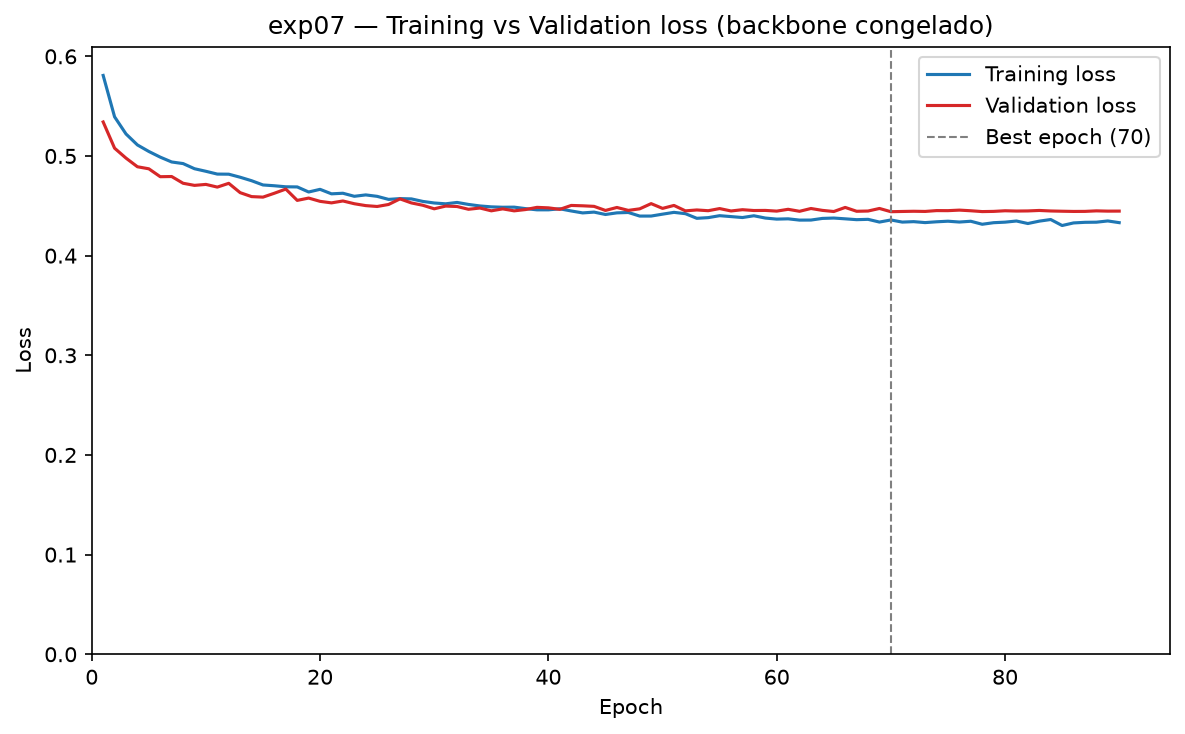

In [17]:
import matplotlib.pyplot as plt

best_epoch = int(np.argmin(val_loss_history)) + 1

for epoch, (t_loss, v_loss) in enumerate(zip(train_loss_history, val_loss_history), start=1):
    marker = "  <-- best (min val loss)" if epoch == best_epoch else ""
    print(f"Epoch {epoch:3d} \t Training Loss: {t_loss:.6f} \t Validation Loss: {v_loss:.6f}{marker}")

loss_history_path = RUN_DIR / "loss_history.csv"
pd.DataFrame({
    "epoch": range(1, len(train_loss_history) + 1),
    "train_loss": train_loss_history,
    "val_loss": val_loss_history,
}).to_csv(loss_history_path, index=False)
print(f"\nHistorial guardado en: {loss_history_path}")

fig, ax = plt.subplots(figsize=(8, 5))
epochs_range = range(1, len(train_loss_history) + 1)
ax.plot(epochs_range, train_loss_history, label="Training loss", color="#1f77b4")
ax.plot(epochs_range, val_loss_history, label="Validation loss", color="#d62728")
ax.axvline(best_epoch, linestyle="--", color="gray", lw=1, label=f"Best epoch ({best_epoch})")
ax.set_xlim(left=0)
ax.set_ylim(0, max(max(train_loss_history), max(val_loss_history)) * 1.05)
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("exp07 — Training vs Validation loss (backbone congelado)")
ax.legend()
fig.tight_layout()

loss_curve_path = PLOTS_DIR / "loss_curve.png"
fig.savefig(loss_curve_path, dpi=150, bbox_inches="tight")
print(f"Figura guardada en: {loss_curve_path}")
plt.show()

In [18]:
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device))
model.eval()

all_labels, all_preds, all_probs = [], [], []
with torch.no_grad():
    for data, labels in tqdm(test, desc="Test", unit="batch"):
        data = data.to(device, dtype=torch.float)
        logits = model(data)
        probs = torch.softmax(logits, dim=-1)[:, 1]
        preds = logits.argmax(dim=-1)

        all_labels.extend(labels.numpy())
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

test_acc = accuracy_score(all_labels, all_preds)
test_auc = roc_auc_score(all_labels, all_probs)

idx_to_label = {v: k for k, v in train_processed.label_to_idx.items()}
print(f"label_to_idx: {train_processed.label_to_idx}  (clase positiva para AUC = {idx_to_label[1]!r})")
print(f"Test accuracy: {test_acc:.4f}")
print(f"Test ROC AUC:  {test_auc:.4f}")
print()
print(classification_report(all_labels, all_preds, target_names=[idx_to_label[0], idx_to_label[1]]))

Test:   0%|          | 0/28 [00:00<?, ?batch/s]

label_to_idx: {'Benign': 0, 'Malignant': 1}  (clase positiva para AUC = 'Malignant')
Test accuracy: 0.7943
Test ROC AUC:  0.8355

              precision    recall  f1-score   support

      Benign       0.83      0.72      0.77       425
   Malignant       0.77      0.86      0.81       455

    accuracy                           0.79       880
   macro avg       0.80      0.79      0.79       880
weighted avg       0.80      0.79      0.79       880



Figura guardada en: /media/imagenesmedicas/DATA1/01-ImagenesMedicas-US1/13-PregradoJulian/Federal Learning/infraestructura federada/Federal-Learning/runs/exp07_resnet50_radimagenet_mammobench_frozen_linearhead/plots/test_confusion_matrix.png


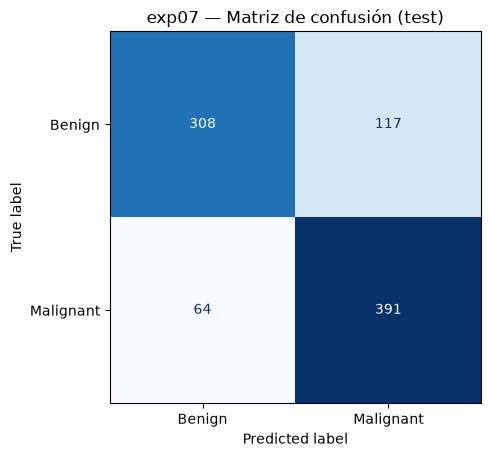

Accuracy  : 0.7943
ROC AUC   : 0.8355
Precision : 0.7697
Recall    : 0.8593
F1-score  : 0.8120
Figura guardada en: /media/imagenesmedicas/DATA1/01-ImagenesMedicas-US1/13-PregradoJulian/Federal Learning/infraestructura federada/Federal-Learning/runs/exp07_resnet50_radimagenet_mammobench_frozen_linearhead/plots/test_roc_curve.png


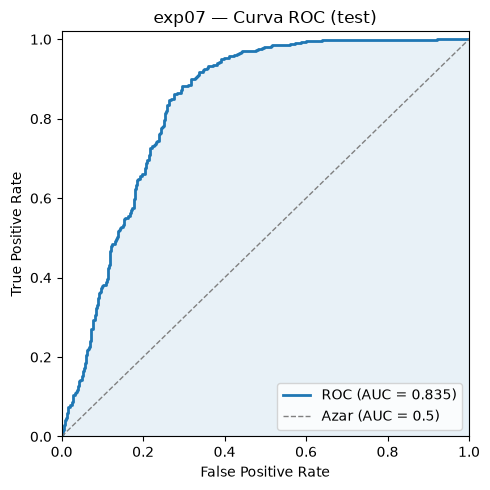

Figura guardada en: /media/imagenesmedicas/DATA1/01-ImagenesMedicas-US1/13-PregradoJulian/Federal Learning/infraestructura federada/Federal-Learning/runs/exp07_resnet50_radimagenet_mammobench_frozen_linearhead/plots/test_metrics_bar.png


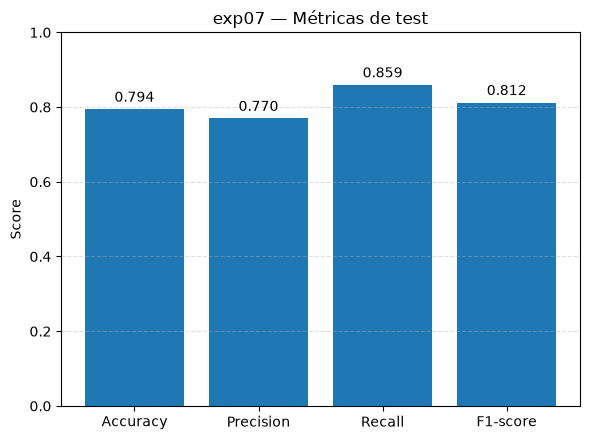

In [17]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score, f1_score, roc_curve

test_precision = precision_score(all_labels, all_preds, pos_label=1)
test_recall = recall_score(all_labels, all_preds, pos_label=1)
test_f1 = f1_score(all_labels, all_preds, pos_label=1)
cm = confusion_matrix(all_labels, all_preds)

class_names = [idx_to_label[0], idx_to_label[1]]

fig_cm, ax_cm = plt.subplots(figsize=(5, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax_cm, cmap="Blues", colorbar=False, values_format="d")
ax_cm.set_title(f"{EXP_ID} — Matriz de confusión (test)")
fig_cm.tight_layout()

cm_path = PLOTS_DIR / "test_confusion_matrix.png"
fig_cm.savefig(cm_path, dpi=150, bbox_inches="tight")
print(f"Figura guardada en: {cm_path}")
plt.show()

metrics = {
    "Accuracy": test_acc,
    "ROC AUC": test_auc,
    "Precision": test_precision,
    "Recall": test_recall,
    "F1-score": test_f1,
}
for name, value in metrics.items():
    print(f"{name:10s}: {value:.4f}")

# ROC AUC es el area bajo la curva ROC: se grafica la curva real, no un punto suelto.
fpr, tpr, _ = roc_curve(all_labels, all_probs)

fig_roc, ax_roc = plt.subplots(figsize=(5, 5))
ax_roc.plot(fpr, tpr, color="#1f77b4", lw=2, label=f"ROC (AUC = {test_auc:.3f})")
ax_roc.fill_between(fpr, tpr, alpha=0.1, color="#1f77b4")
ax_roc.plot([0, 1], [0, 1], linestyle="--", color="gray", lw=1, label="Azar (AUC = 0.5)")
ax_roc.set_xlim(0, 1)
ax_roc.set_ylim(0, 1.02)
ax_roc.set_xlabel("False Positive Rate")
ax_roc.set_ylabel("True Positive Rate")
ax_roc.set_title(f"{EXP_ID} — Curva ROC (test)")
ax_roc.legend(loc="lower right")
fig_roc.tight_layout()

roc_path = PLOTS_DIR / "test_roc_curve.png"
fig_roc.savefig(roc_path, dpi=150, bbox_inches="tight")
print(f"Figura guardada en: {roc_path}")
plt.show()

# Accuracy/Precision/Recall/F1 son escalares puntuales en el mismo rango [0, 1]: se
# comparan mejor juntos en un solo grafico de barras que en 4 graficos de un punto.
bar_metrics = {k: v for k, v in metrics.items() if k != "ROC AUC"}

fig_bar, ax_bar = plt.subplots(figsize=(6, 4.5))
bars = ax_bar.bar(bar_metrics.keys(), bar_metrics.values(), color="#1f77b4")
ax_bar.set_ylim(0, 1)
ax_bar.set_ylabel("Score")
ax_bar.set_title(f"{EXP_ID} — Métricas de test")
ax_bar.grid(True, axis="y", linestyle="--", alpha=0.4)
ax_bar.bar_label(bars, fmt="%.3f", padding=3)
fig_bar.tight_layout()

bar_path = PLOTS_DIR / "test_metrics_bar.png"
fig_bar.savefig(bar_path, dpi=150, bbox_inches="tight")
print(f"Figura guardada en: {bar_path}")
plt.show()

In [20]:
summary = {
    "experiment": EXP_ID,
    "block": BLOCK,
    "run_name": RUN_NAME,
    "unfrozen": UNFROZEN_DESC,
    "hyperparams": {
        "head": HEAD,
        "dropout": DROPOUT if HEAD == "mlp" else None,
        "lr": LR,
        "weight_decay": WEIGHT_DECAY,
        "batch_size": BATCH_SIZE,
        "num_epochs": NUM_EPOCHS,
        "patience": PATIENCE,
        "image_size": IMAGE_SIZE,
        "optimizer": "AdamW",
        "scheduler": "CosineAnnealingLR",
        "augmentation": f"RandomRotation({ROTATION_DEGREES})",
    },
    "epochs_run": len(train_loss_history),
    "best_epoch": best_epoch,
    "best_val_loss": float(min(val_loss_history)),
    "final_train_loss": float(train_loss_history[-1]),
    "final_val_loss": float(val_loss_history[-1]),
    "test": {
        "accuracy": float(test_acc),
        "auc": float(test_auc),
        "precision": float(test_precision),
        "recall": float(test_recall),
        "f1": float(test_f1),
        "confusion_matrix": cm.tolist(),
        "class_names": class_names,
    },
    "checkpoints": {
        "best": str(BEST_MODEL_PATH),
        "last": str(LAST_MODEL_PATH),
    },
}

metrics_path = RUN_DIR / "metrics.json"
metrics_path.write_text(json.dumps(summary, indent=2))
print(f"Resumen guardado en: {metrics_path}")
print(json.dumps(summary["test"], indent=2))

Resumen guardado en: /media/imagenesmedicas/DATA1/01-ImagenesMedicas-US1/13-PregradoJulian/Federal Learning/infraestructura federada/Federal-Learning/runs/exp07_resnet50_radimagenet_mammobench_frozen_linearhead/metrics.json
{
  "accuracy": 0.7943181818181818,
  "auc": 0.835459599224305,
  "precision": 0.7696850393700787,
  "recall": 0.8593406593406593,
  "f1": 0.8120456905503635,
  "confusion_matrix": [
    [
      308,
      117
    ],
    [
      64,
      391
    ]
  ],
  "class_names": [
    "Benign",
    "Malignant"
  ]
}
